In [1]:
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import max, col, countDistinct, count, desc, first, when, abs, avg, length, split, explode, lower, lag
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pyspark.sql.window import Window

In [2]:
spark = SparkSession.builder \
    .appName("wiki_eda") \
    .master("local[*]") \
    .getOrCreate()

print(f"Spark version: {spark.version}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/21 20:44:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.0


In [3]:
df_wiki = spark.read.parquet("/big-data/hive/warehouse/wikipedia_silver")
df_wiki.printSchema()
df_wiki.show(5)

root
 |-- id: long (nullable = true)
 |-- title: string (nullable = true)
 |-- page_url: string (nullable = true)
 |-- comment: string (nullable = true)
 |-- event_timestamp: long (nullable = true)
 |-- minor: boolean (nullable = true)
 |-- bot: boolean (nullable = true)
 |-- username: string (nullable = true)
 |-- length_old: integer (nullable = true)
 |-- length_new: integer (nullable = true)
 |-- event_date: date (nullable = true)

+----------+--------------------+--------------------+--------------------+---------------+-----+-----+--------------------+----------+----------+----------+
|        id|               title|            page_url|             comment|event_timestamp|minor|  bot|            username|length_old|length_new|event_date|
+----------+--------------------+--------------------+--------------------+---------------+-----+-----+--------------------+----------+----------+----------+
|1977614357|List of Marvel Co...|https://en.wikipe...|/* Fabian Cortez ...|     1766258

In [4]:
row_count = df_wiki.count()
print(f"Total rows: {row_count}")

Total rows: 17625


In [5]:
# check nulls
null_counts = {col_name: df_wiki.filter(col(col_name).isNull()).count() for col_name in df_wiki.columns}
print("Null counts per column:")
for col_name, null_count in null_counts.items():
    print(f"  {col_name}: {null_count}")

Null counts per column:
  id: 0
  title: 0
  page_url: 0
  comment: 0
  event_timestamp: 0
  minor: 0
  bot: 0
  username: 0
  length_old: 0
  length_new: 0
  event_date: 0


25/12/21 20:44:33 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


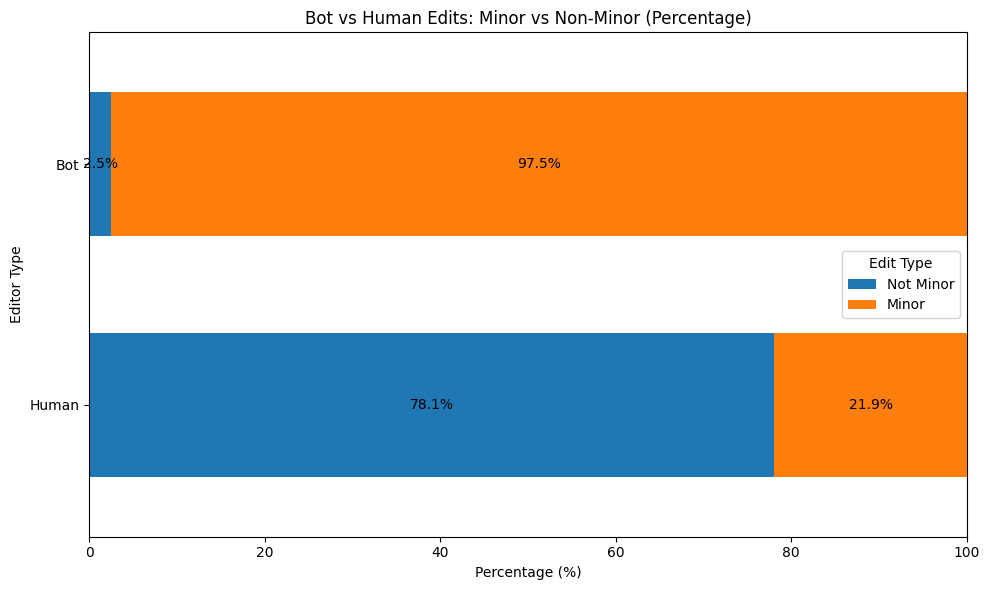

In [6]:
bot_minor_data = df_wiki.groupBy("bot", "minor").count().toPandas()

pivot_data = bot_minor_data.pivot(index='bot', columns='minor', values='count').fillna(0)
pivot_data.index = pivot_data.index.map({True: 'Bot', False: 'Human'})
pivot_data.columns = ['Not Minor', 'Minor']

pivot_data_pct = pivot_data.div(pivot_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
pivot_data_pct.plot(kind='barh', stacked=True, ax=ax, width=0.6)
plt.title('Bot vs Human Edits: Minor vs Non-Minor (Percentage)')
plt.xlabel('Percentage (%)')
plt.ylabel('Editor Type')
plt.legend(title='Edit Type')
plt.xlim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.tight_layout()
plt.show()

Most of the time, bots just make small, minor fixes (97.5%), while humans usually make bigger, important changes (78.1%).

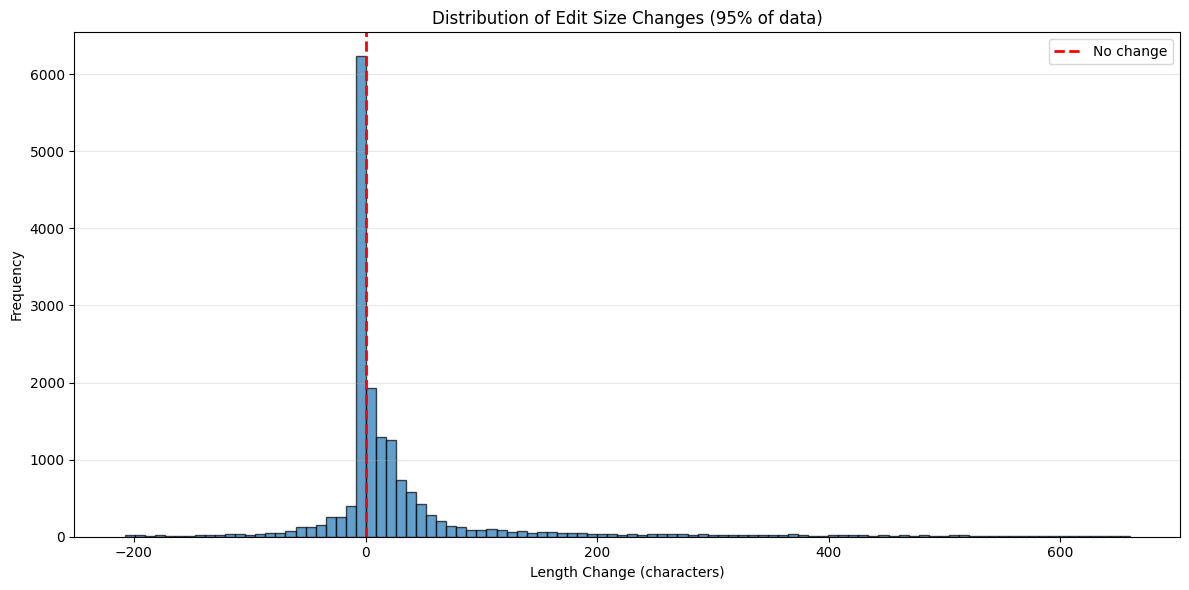

In [7]:
df_length_diff = df_wiki.withColumn("length_diff", col("length_new") - col("length_old"))

length_diff_data = df_length_diff.select("length_diff").toPandas()

# filtering out outliers using 2.5th and 97.5th percentiles so the distribution is clearer
q1 = length_diff_data['length_diff'].quantile(0.025)
q99 = length_diff_data['length_diff'].quantile(0.975)
filtered_data = length_diff_data[(length_diff_data['length_diff'] >= q1) & 
                                  (length_diff_data['length_diff'] <= q99)]

fig, ax = plt.subplots(figsize=(12, 6))
plt.hist(filtered_data['length_diff'], bins=100, edgecolor='black', alpha=0.7)
plt.title('Distribution of Edit Size Changes (95% of data)')
plt.xlabel('Length Change (characters)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No change')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The histogram reveals that the overwhelming majority of edits are "micro-edits" centered right around zero, indicating that users primarily focus on small fixes like typos or single-word changes. The distribution is skewed to the right, showing that users are far more likely to add new content (growing the text) than to delete large sections.

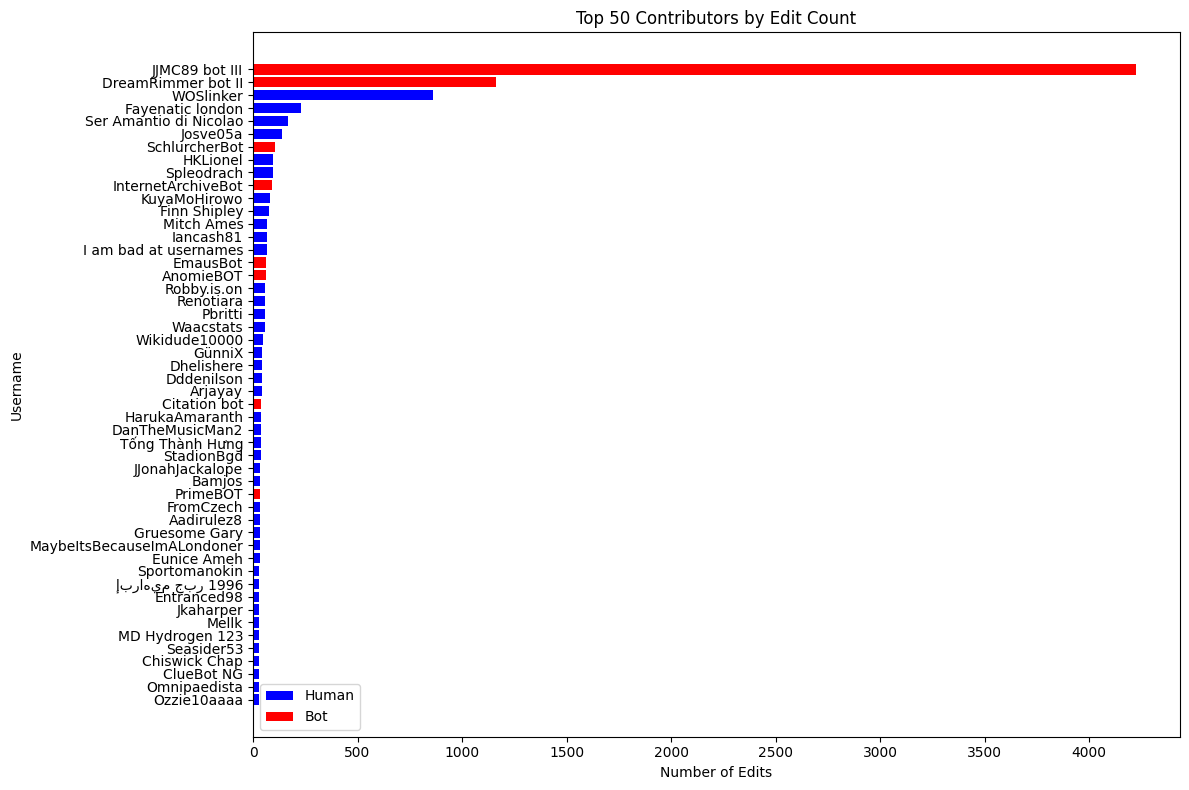

In [8]:
top_users = df_wiki.groupBy("username") \
    .agg(
        count("*").alias("edit_count"),
        first("bot").alias("is_bot")
    ) \
    .orderBy(desc("edit_count")) \
    .limit(50) \
    .toPandas()

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['red' if is_bot else 'blue' for is_bot in top_users['is_bot']]
plt.barh(top_users['username'], top_users['edit_count'], color=colors)
plt.xlabel('Number of Edits')
plt.ylabel('Username')
plt.title('Top 50 Contributors by Edit Count')
plt.gca().invert_yaxis()

legend_elements = [
    Patch(facecolor='blue', label='Human'),
    Patch(facecolor='red', label='Bot')
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

A few bots appear at the very top of the list with thousands of edits. In contrast, top humans make fewer changes overall, but there is more of them in the ranking.

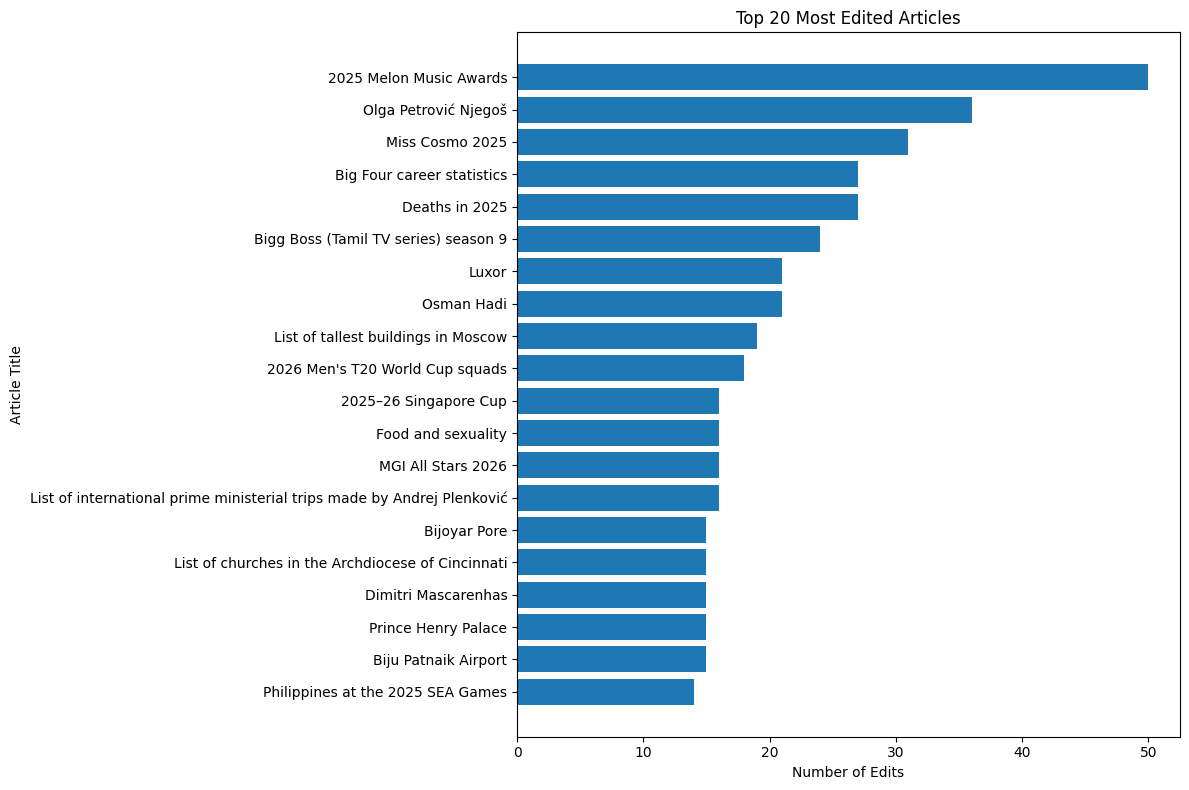

In [9]:
top_articles = df_wiki.groupBy("title") \
    .agg(count("*").alias("edit_count")) \
    .orderBy(desc("edit_count")) \
    .limit(20) \
    .toPandas()

fig, ax = plt.subplots(figsize=(12, 8))
plt.barh(top_articles['title'], top_articles['edit_count'])
plt.xlabel('Number of Edits')
plt.ylabel('Article Title')
plt.title('Top 20 Most Edited Articles')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

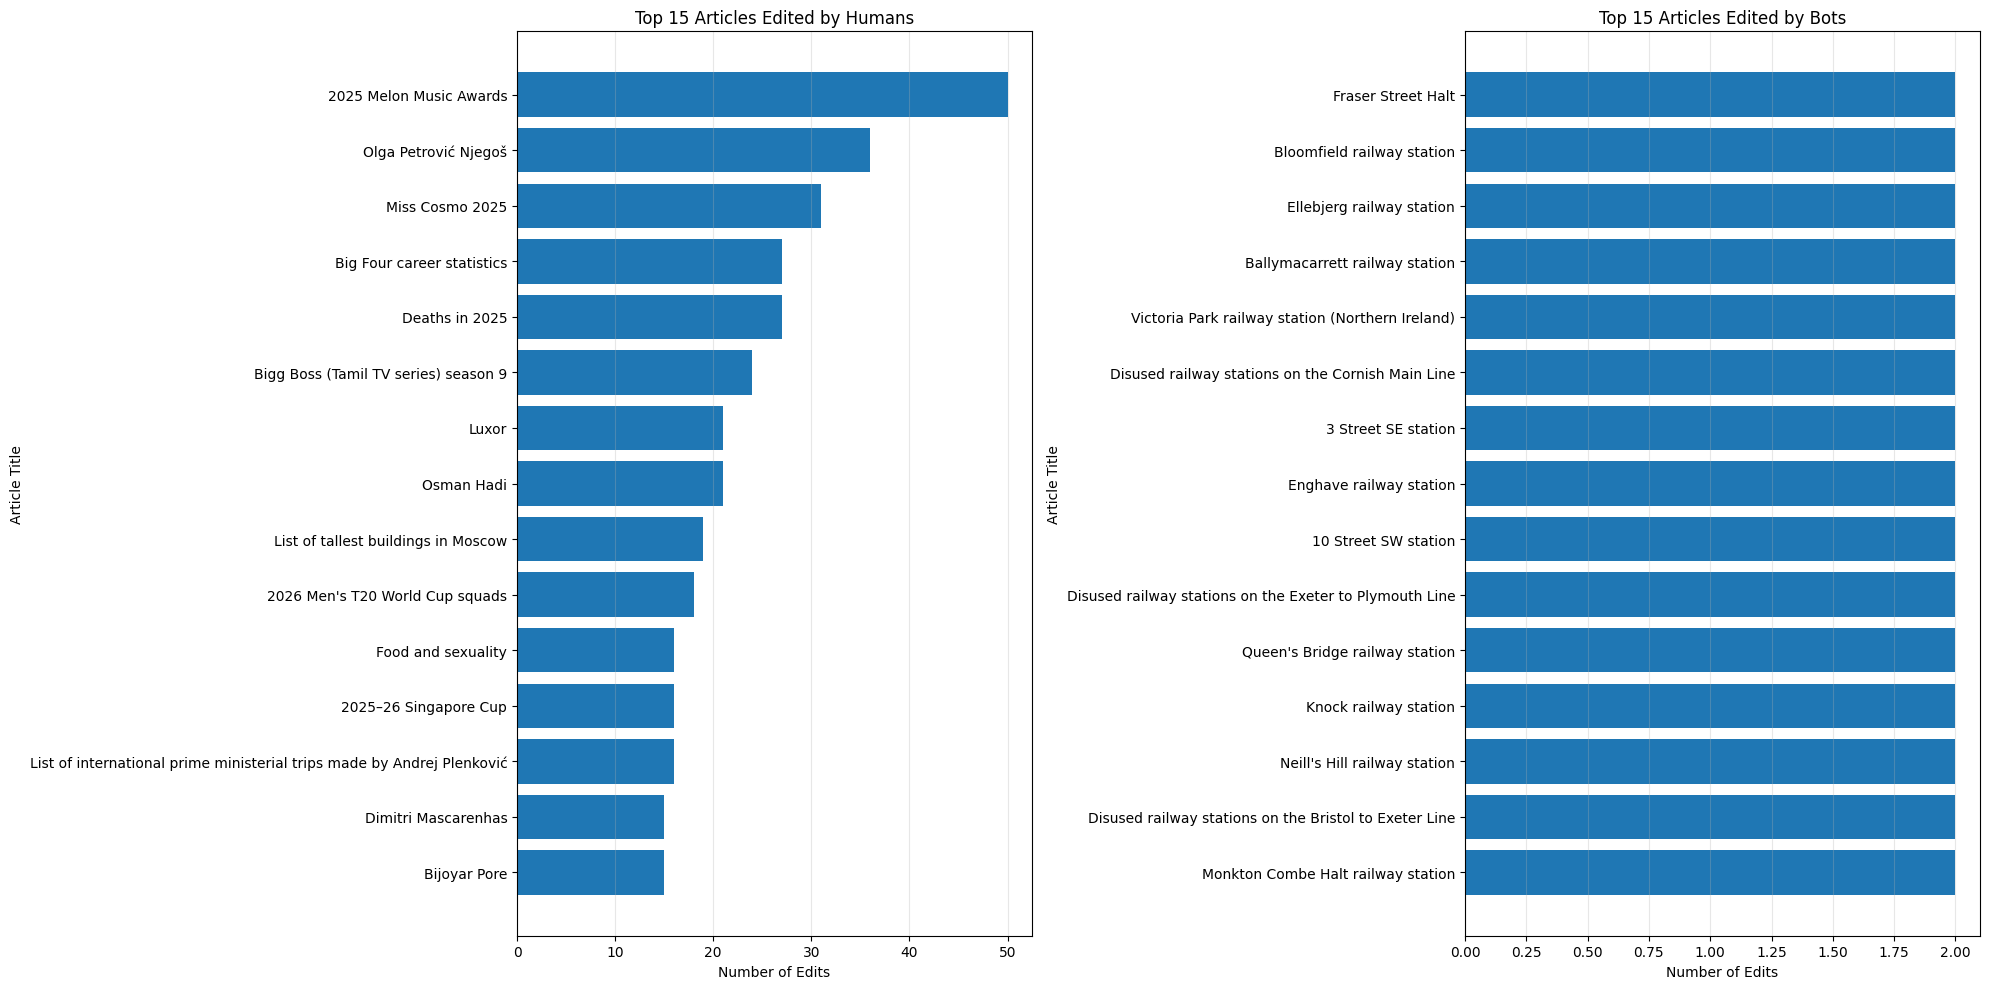

In [10]:
top_bot_articles = df_wiki.filter(col("bot") == True) \
    .groupBy("title") \
    .agg(count("*").alias("edit_count")) \
    .orderBy(desc("edit_count")) \
    .limit(15) \
    .toPandas()

top_human_articles = df_wiki.filter(col("bot") == False) \
    .groupBy("title") \
    .agg(count("*").alias("edit_count")) \
    .orderBy(desc("edit_count")) \
    .limit(15) \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].barh(top_human_articles['title'], top_human_articles['edit_count'])
axes[0].set_xlabel('Number of Edits')
axes[0].set_ylabel('Article Title')
axes[0].set_title('Top 15 Articles Edited by Humans')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(top_bot_articles['title'], top_bot_articles['edit_count'])
axes[1].set_xlabel('Number of Edits')
axes[1].set_ylabel('Article Title')
axes[1].set_title('Top 15 Articles Edited by Bots')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Bots are not interested in the same articles as humans do. Bots do small amount of edits to singular articles and humans fight over popular articles.

In [11]:
unique_articles = df_wiki.select(countDistinct("title")).collect()[0][0]
avg_edits_per_article = row_count / unique_articles

print("=== Article Statistics ===")
print(f"Total unique articles: {unique_articles:,}")
print(f"Total edits: {row_count:,}")
print(f"Average edits per article: {avg_edits_per_article:.2f}")

edits_per_article = df_wiki.groupBy("title") \
    .agg(count("*").alias("edit_count")) \
    .select("edit_count") \
    .toPandas()

print(f"\nMedian edits per article: {edits_per_article['edit_count'].median():.0f}")
print(f"Min edits per article: {edits_per_article['edit_count'].min()}")
print(f"Max edits per article: {edits_per_article['edit_count'].max()}")
print(f"Std deviation: {edits_per_article['edit_count'].std():.2f}")

print(f"\n25th percentile: {edits_per_article['edit_count'].quantile(0.25):.0f} edits")
print(f"50th percentile: {edits_per_article['edit_count'].quantile(0.50):.0f} edits")
print(f"75th percentile: {edits_per_article['edit_count'].quantile(0.75):.0f} edits")
print(f"95th percentile: {edits_per_article['edit_count'].quantile(0.95):.0f} edits")

article_stats = df_wiki.groupBy("bot") \
    .agg(countDistinct("title").alias("unique_articles")) \
    .toPandas()

article_stats['user_type'] = article_stats['bot'].map({True: 'Bot', False: 'Human'})

print(f"\n=== Articles Edited by Type ===")
for _, row in article_stats.iterrows():
    print(f"{row['user_type']}: {row['unique_articles']:,} unique articles")

bot_articles = df_wiki.filter(col("bot") == True).select("title").distinct()
human_articles = df_wiki.filter(col("bot") == False).select("title").distinct()

bot_only = bot_articles.subtract(human_articles).count()
human_only = human_articles.subtract(bot_articles).count()
both = bot_articles.intersect(human_articles).count()

print(f"\n=== Article Overlap ===")
print(f"Articles edited only by bots: {bot_only:,}")
print(f"Articles edited only by humans: {human_only:,}")
print(f"Articles edited by both: {both:,}")

=== Article Statistics ===
Total unique articles: 13,949
Total edits: 17,625
Average edits per article: 1.26



Median edits per article: 1
Min edits per article: 1
Max edits per article: 50
Std deviation: 1.24

25th percentile: 1 edits
50th percentile: 1 edits
75th percentile: 1 edits
95th percentile: 2 edits

=== Articles Edited by Type ===
Bot: 5,778 unique articles
Human: 8,222 unique articles



=== Article Overlap ===
Articles edited only by bots: 5,727
Articles edited only by humans: 8,171
Articles edited by both: 51


Most articles are edited very few times, with the majority receiving only one edit and only a small number getting more than two edits. Humans edit more unique articles than bots, but bots still contribute to a large portion of articles. Very few articles are edited by both bots and humans, showing that their work rarely overlaps.

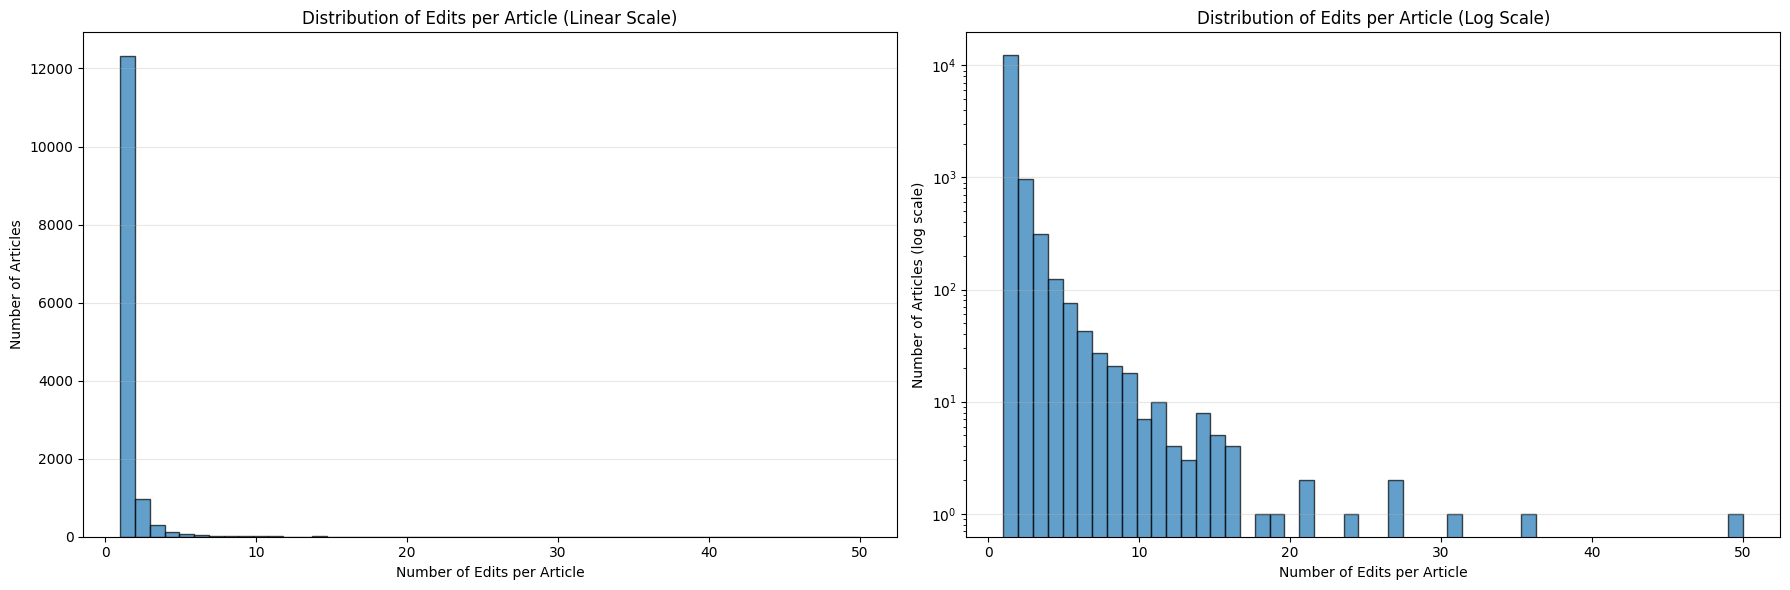

In [12]:
edits_per_article = df_wiki.groupBy("title") \
    .agg(count("*").alias("edit_count")) \
    .select("edit_count") \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].hist(edits_per_article['edit_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Edits per Article')
axes[0].set_ylabel('Number of Articles')
axes[0].set_title('Distribution of Edits per Article (Linear Scale)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(edits_per_article['edit_count'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Edits per Article')
axes[1].set_ylabel('Number of Articles (log scale)')
axes[1].set_title('Distribution of Edits per Article (Log Scale)')
axes[1].set_yscale('log')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Most articles are edited only once and then left alone, showing that ongoing collaboration is rare. A small number of articles receive many edits, meaning they attract much more attention than the rest. Overall, editing activity is uneven, with a few popular articles getting most of the focus while most others stay inactive.

In [13]:
print("=== Comment Analysis ===")

total_edits = df_wiki.count()
comments_present = df_wiki.filter(col("comment").isNotNull() & (col("comment") != "")).count()
comments_missing = total_edits - comments_present

print(f"Total edits: {total_edits:,}")
print(f"Edits with comments: {comments_present:,} ({comments_present/total_edits*100:.1f}%)")
print(f"Edits without comments: {comments_missing:,} ({comments_missing/total_edits*100:.1f}%)")

comment_stats = df_wiki.withColumn("has_comment", 
                                    (col("comment").isNotNull()) & (col("comment") != "")) \
    .groupBy("bot", "has_comment") \
    .count() \
    .toPandas()

print("\n=== Comments by Editor Type ===")
for bot_type in [False, True]:
    subset = comment_stats[comment_stats['bot'] == bot_type]
    editor_type = "Human" if not bot_type else "Bot"
    total = subset['count'].sum()
    with_comment = subset[subset['has_comment'] == True]['count'].values
    with_comment = with_comment[0] if len(with_comment) > 0 else 0
    print(f"{editor_type}: {with_comment:,}/{total:,} ({with_comment/total*100:.1f}%) have comments")

=== Comment Analysis ===


Total edits: 17,625
Edits with comments: 15,445 (87.6%)
Edits without comments: 2,180 (12.4%)

=== Comments by Editor Type ===
Human: 9,651/11,831 (81.6%) have comments
Bot: 5,794/5,794 (100.0%) have comments


Bots always add comments to their edits. Humans mostly do but sometimes they don't.

In [14]:
df_with_comment_length = df_wiki.filter(col("comment").isNotNull() & (col("comment") != "")) \
    .withColumn("comment_length", length(col("comment")))

comment_length_stats = df_with_comment_length.select("comment_length").toPandas()

print("\n=== Comment Length Statistics ===")
print(f"Mean length: {comment_length_stats['comment_length'].mean():.2f} characters")
print(f"Median length: {comment_length_stats['comment_length'].median():.0f} characters")
print(f"Max length: {comment_length_stats['comment_length'].max()} characters")


=== Comment Length Statistics ===
Mean length: 112.24 characters
Median length: 66 characters
Max length: 500 characters


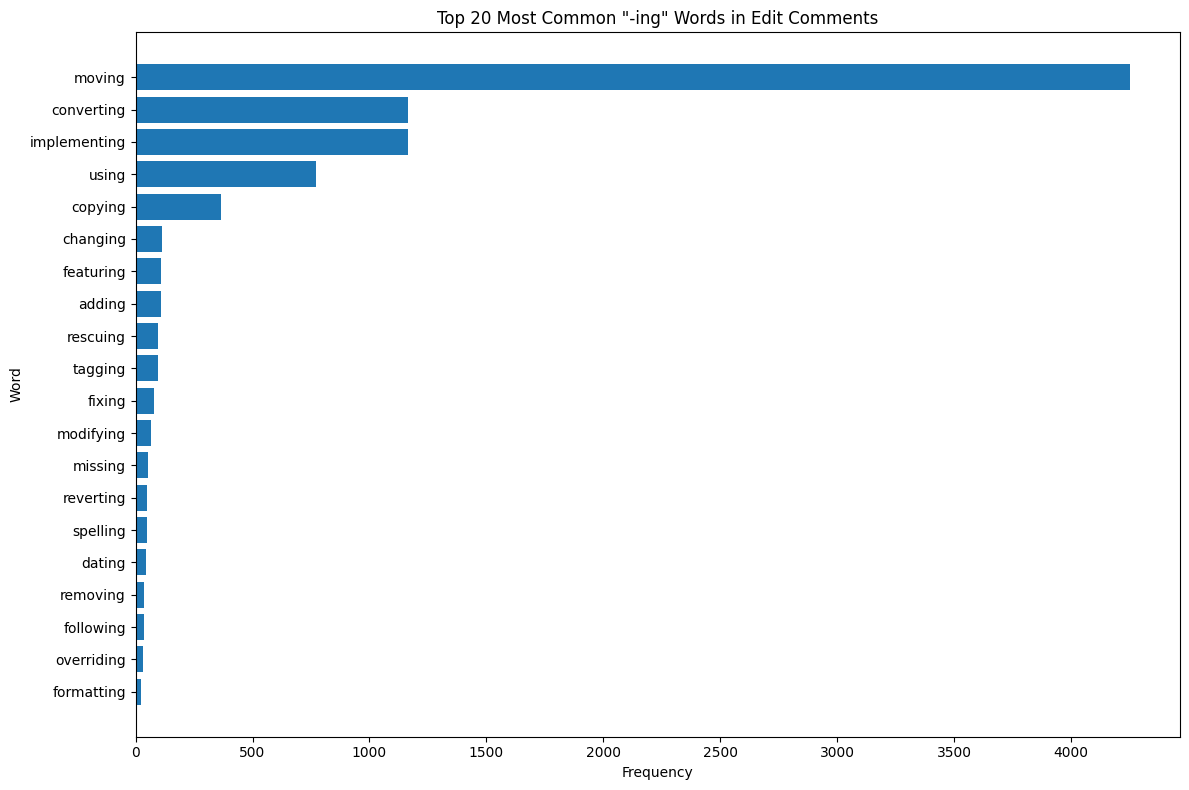

In [15]:
# extract all words ending with 'ing' from comments
df_with_words = df_wiki.filter(col("comment").isNotNull() & (col("comment") != "")) \
    .withColumn("comment_lower", lower(col("comment"))) \
    .withColumn("words", split(col("comment_lower"), r'\W+'))

df_words_exploded = df_with_words.select(explode(col("words")).alias("word"), "bot")

df_ing_words = df_words_exploded.filter(col("word").endswith("ing") & (col("word") != ""))

top_ing_words = df_ing_words.groupBy("word") \
    .count() \
    .orderBy(desc("count")) \
    .limit(30) \
    .toPandas()

fig, ax = plt.subplots(figsize=(12, 8))
plt.barh(top_ing_words.head(20)['word'], top_ing_words.head(20)['count'])
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.title('Top 20 Most Common "-ing" Words in Edit Comments')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Most edit comments focus on technical and structural tasks like moving, converting, and fixing pages rather than writing new content.

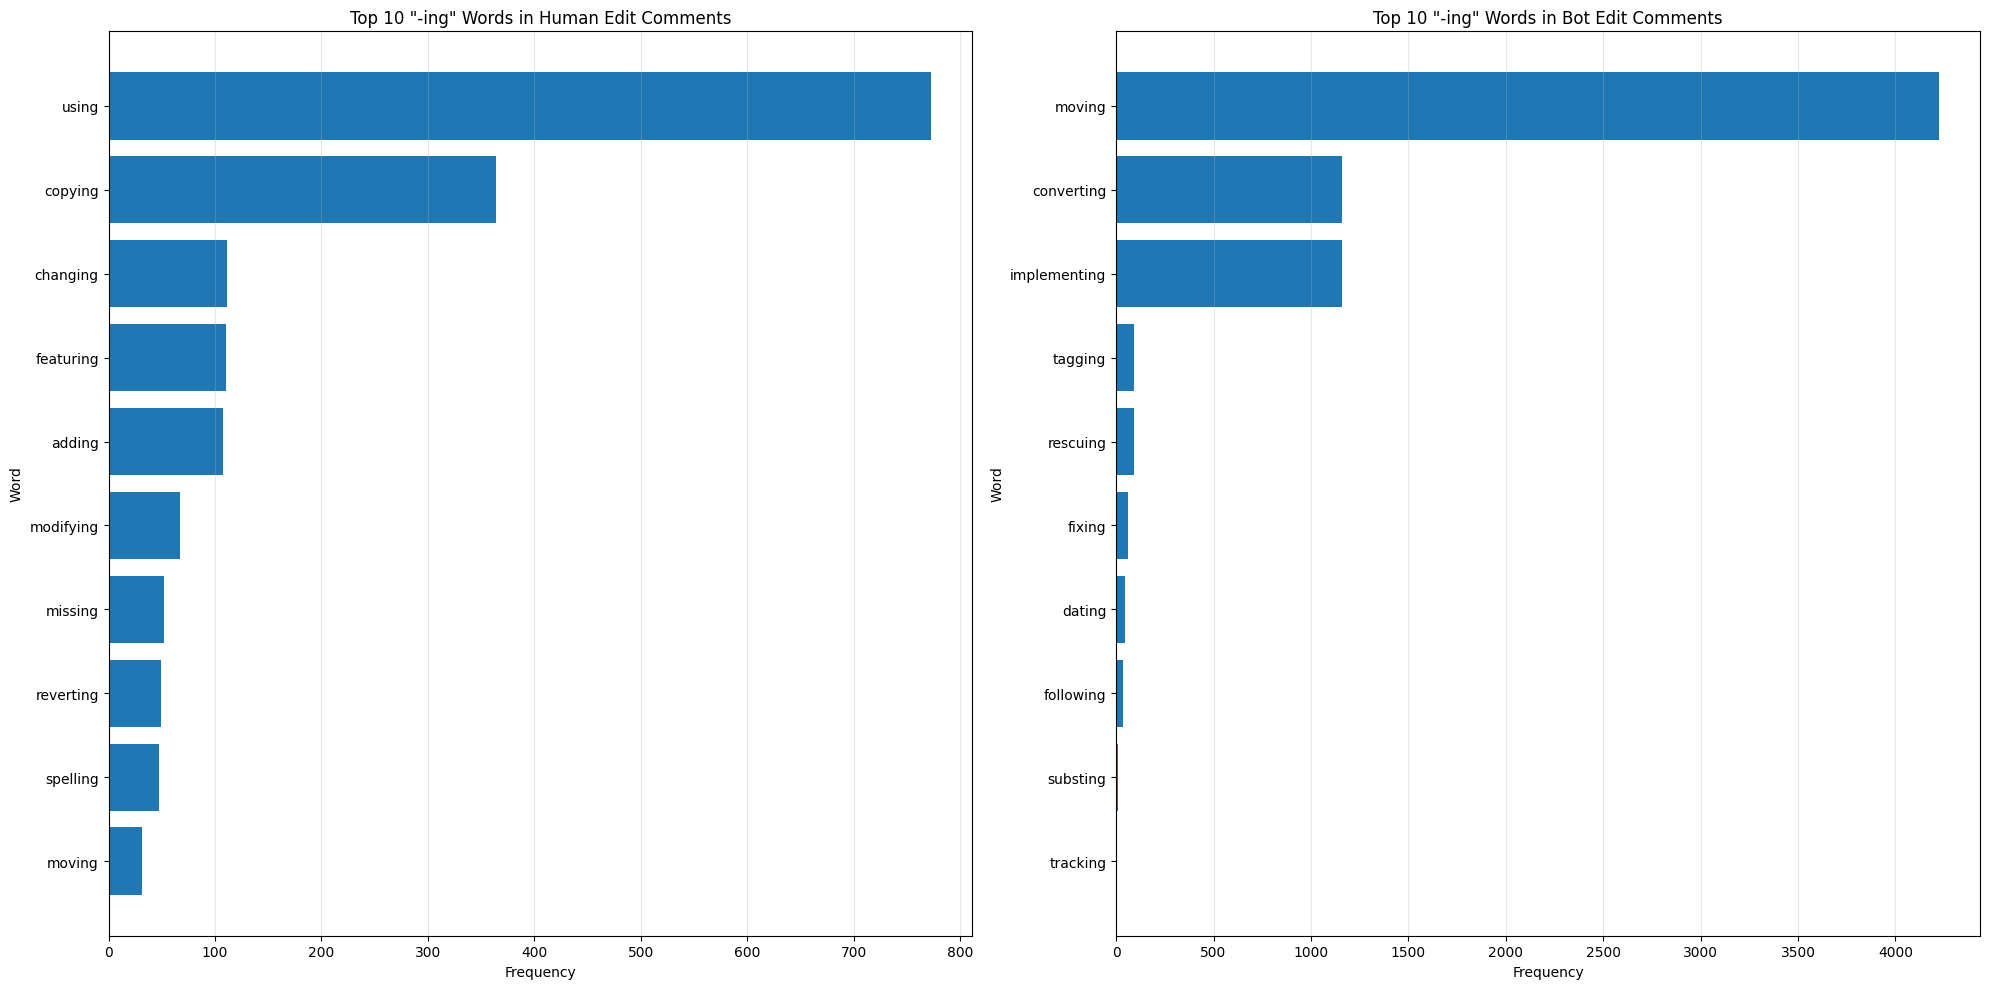

In [16]:
top_human_ing = df_ing_words.filter(col("bot") == False) \
    .groupBy("word") \
    .count() \
    .orderBy(desc("count")) \
    .limit(10) \
    .toPandas()

top_bot_ing = df_ing_words.filter(col("bot") == True) \
    .groupBy("word") \
    .count() \
    .orderBy(desc("count")) \
    .limit(10) \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].barh(top_human_ing['word'], top_human_ing['count'])
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Word')
axes[0].set_title('Top 10 "-ing" Words in Human Edit Comments')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(top_bot_ing['word'], top_bot_ing['count'])
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Word')
axes[1].set_title('Top 10 "-ing" Words in Bot Edit Comments')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Bots mainly handle large, repetitive tasks like moving and converting pages, which explains why these actions appear so often overall. Humans do a wider mix of smaller tasks, such as adding content, fixing mistakes, and reverting bad edits, which require judgment. This shows a clear division of labor: bots manage bulk maintenance, while humans focus on careful editing and decision-making.

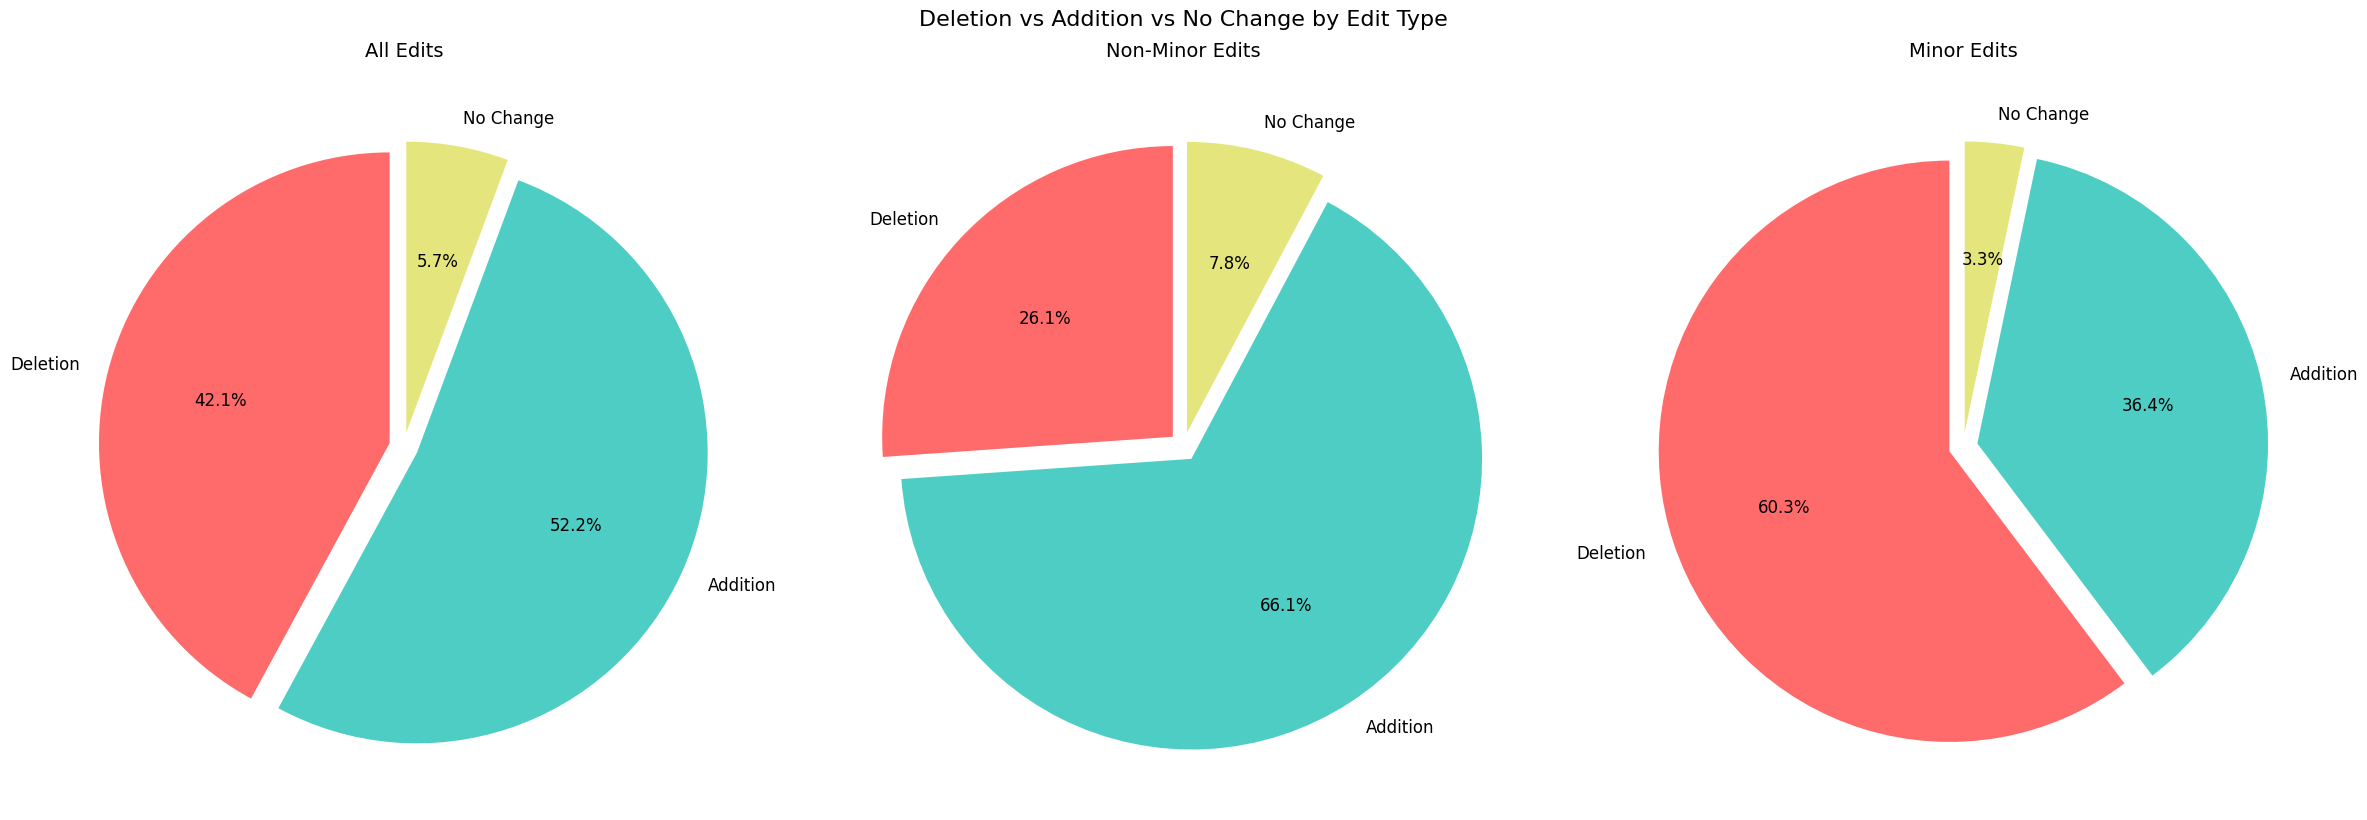

In [17]:
df_with_edit_type_all = df_wiki.withColumn("length_diff", col("length_new") - col("length_old")) \
    .withColumn("edit_type", 
                when(col("length_diff") < 0, "Deletion")
                .when(col("length_diff") > 0, "Addition")
                .otherwise("No Change"))

df_with_edit_type_not_minor = df_wiki.filter(col("minor") == False) \
    .withColumn("length_diff", col("length_new") - col("length_old")) \
    .withColumn("edit_type", 
                when(col("length_diff") < 0, "Deletion")
                .when(col("length_diff") > 0, "Addition")
                .otherwise("No Change"))

df_with_edit_type_minor = df_wiki.filter(col("minor") == True) \
    .withColumn("length_diff", col("length_new") - col("length_old")) \
    .withColumn("edit_type", 
                when(col("length_diff") < 0, "Deletion")
                .when(col("length_diff") > 0, "Addition")
                .otherwise("No Change"))

edit_type_counts_all = df_with_edit_type_all.groupBy("edit_type").count().toPandas()
edit_type_counts_not_minor = df_with_edit_type_not_minor.groupBy("edit_type").count().toPandas()
edit_type_counts_minor = df_with_edit_type_minor.groupBy("edit_type").count().toPandas()

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

colors = ['#ff6b6b', '#4ecdc4', "#e4e67d"]
explode = (0.05, 0.05, 0.05)

axes[0].pie(edit_type_counts_all['count'], 
            labels=edit_type_counts_all['edit_type'],
            autopct='%1.1f%%',
            colors=colors,
            explode=explode,
            startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('All Edits', fontsize=14, pad=20)

axes[1].pie(edit_type_counts_not_minor['count'], 
            labels=edit_type_counts_not_minor['edit_type'],
            autopct='%1.1f%%',
            colors=colors,
            explode=explode,
            startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Non-Minor Edits', fontsize=14, pad=20)

axes[2].pie(edit_type_counts_minor['count'], 
            labels=edit_type_counts_minor['edit_type'],
            autopct='%1.1f%%',
            colors=colors,
            explode=explode,
            startangle=90,
            textprops={'fontsize': 12})
axes[2].set_title('Minor Edits', fontsize=14, pad=20)

fig.suptitle('Deletion vs Addition vs No Change by Edit Type', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Overall, articles are growing, since more edits add content than remove it. Non-minor edits (mostly done by humans) focus on creating and expanding articles, while minor edits focus more on removing or cleaning up content. This shows a clear split between building new content and maintaining existing pages.

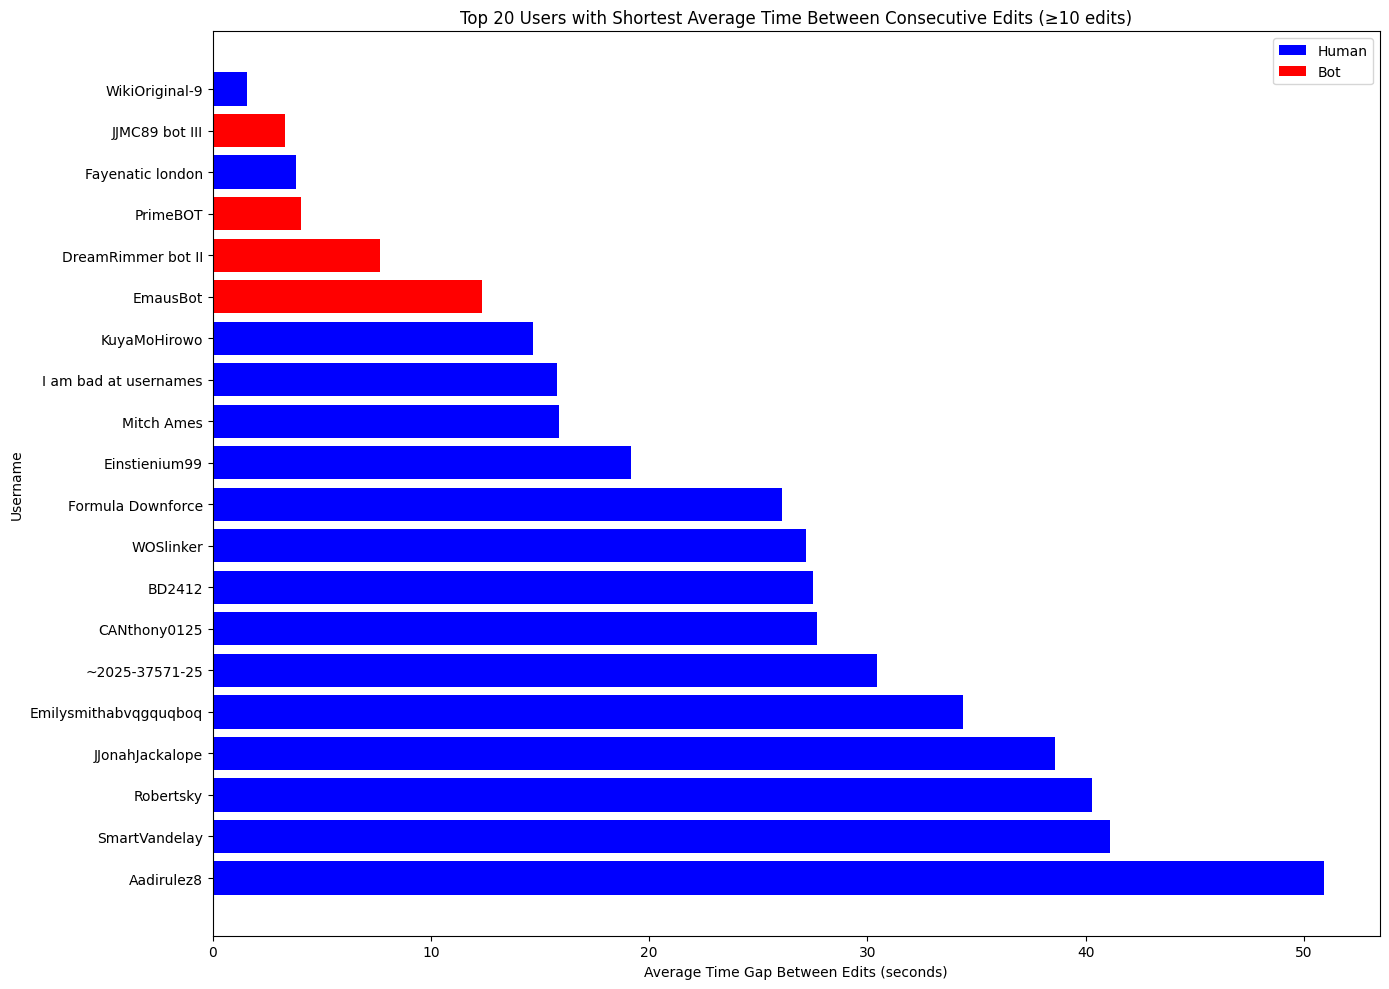

In [18]:
window_spec = Window.partitionBy("username").orderBy("event_timestamp")

df_with_time_diff = df_wiki.withColumn("prev_timestamp", lag("event_timestamp").over(window_spec)) \
    .withColumn("time_diff_seconds", col("event_timestamp") - col("prev_timestamp"))

user_time_gaps = df_with_time_diff.filter(col("time_diff_seconds").isNotNull()) \
    .groupBy("username") \
    .agg(
        avg("time_diff_seconds").alias("avg_time_gap_seconds"),
        count("*").alias("edit_count"),
        first("bot").alias("is_bot")
    ) \
    .filter(col("edit_count") >= 10) \
    .orderBy("avg_time_gap_seconds") \
    .limit(20) \
    .toPandas()

fig, ax = plt.subplots(figsize=(14, 10))
colors = ['red' if is_bot else 'blue' for is_bot in user_time_gaps['is_bot']]
plt.barh(user_time_gaps['username'], user_time_gaps['avg_time_gap_seconds'], color=colors)
plt.xlabel('Average Time Gap Between Edits (seconds)')
plt.ylabel('Username')
plt.title('Top 20 Users with Shortest Average Time Between Consecutive Edits (≥10 edits)')
plt.gca().invert_yaxis()

legend_elements = [
    Patch(facecolor='blue', label='Human'),
    Patch(facecolor='red', label='Bot')
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

There are some "humans" even faster than bots which suggests they might be using some tools to edit so fast, effectively being bots themselves.

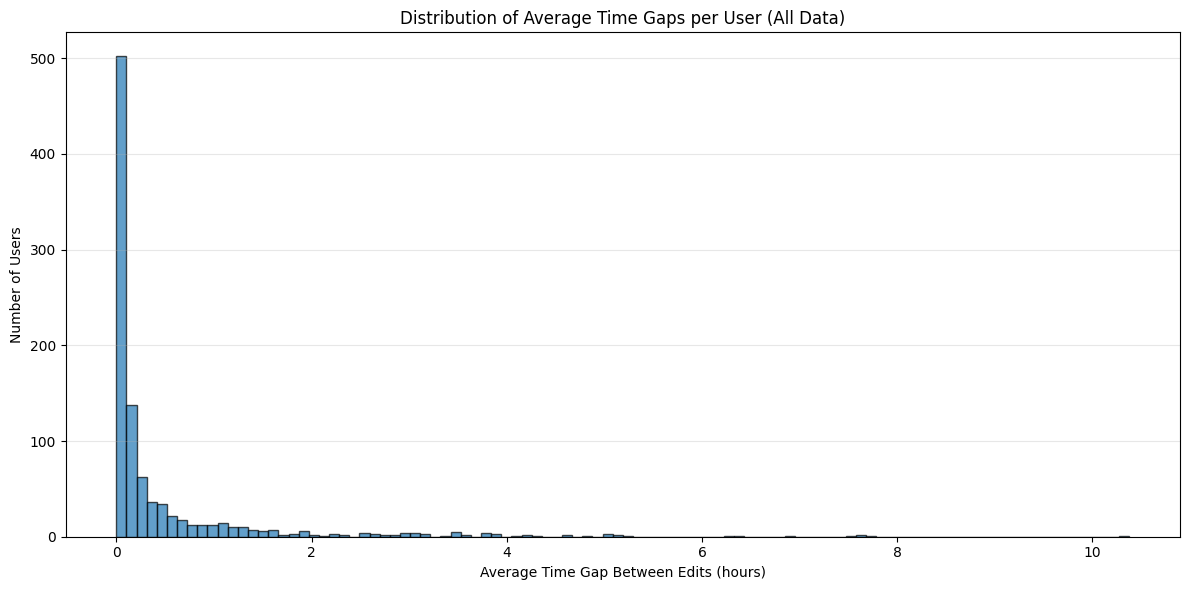

In [19]:
user_avg_time_gaps = df_with_time_diff.filter(col("time_diff_seconds").isNotNull()) \
    .groupBy("username") \
    .agg(
        avg("time_diff_seconds").alias("avg_time_gap_seconds"),
        count("*").alias("edit_count"),
        first("bot").alias("is_bot")
    ) \
    .filter(col("edit_count") >= 2) \
    .toPandas()

user_avg_time_gaps['avg_time_gap_hours'] = user_avg_time_gaps['avg_time_gap_seconds'] / 3600

fig, ax = plt.subplots(figsize=(12, 6))
plt.hist(user_avg_time_gaps['avg_time_gap_hours'], bins=100, edgecolor='black', alpha=0.7)
plt.xlabel('Average Time Gap Between Edits (hours)')
plt.ylabel('Number of Users')
plt.title('Distribution of Average Time Gaps per User (All Data)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Most users edit in short, concentrated sessions, making several changes in rapid succession rather than spreading edits throughout the day. Only a few users have longer gaps between edits, representing occasional or casual contributors. Overall, editing activity is highly session-based, with bursts of rapid work being the norm.

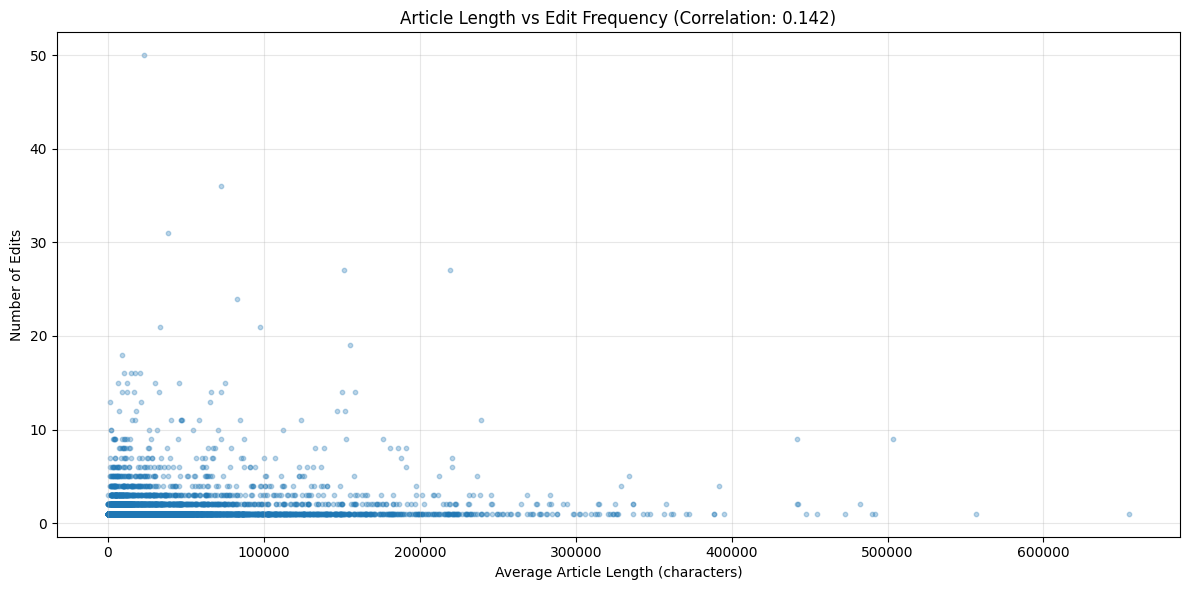

In [20]:
article_stats = df_wiki.groupBy("title") \
    .agg(
        count("*").alias("edit_count"),
        avg("length_new").alias("avg_length"),
        max("length_new").alias("max_length")
    ) \
    .toPandas()

correlation = article_stats['edit_count'].corr(article_stats['avg_length'])

fig, ax = plt.subplots(figsize=(12, 6))
plt.scatter(article_stats['avg_length'], article_stats['edit_count'], alpha=0.3, s=10)
plt.xlabel('Average Article Length (characters)')
plt.ylabel('Number of Edits')
plt.title(f'Article Length vs Edit Frequency (Correlation: {correlation:.3f})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

There is almost no link between article length and how often it gets edited, as shown by the very weak correlation. Most edits happen on small to medium-length articles, while extremely large articles are rarely touched. This suggests the community focuses on manageable content, leaving massive pages largely static.

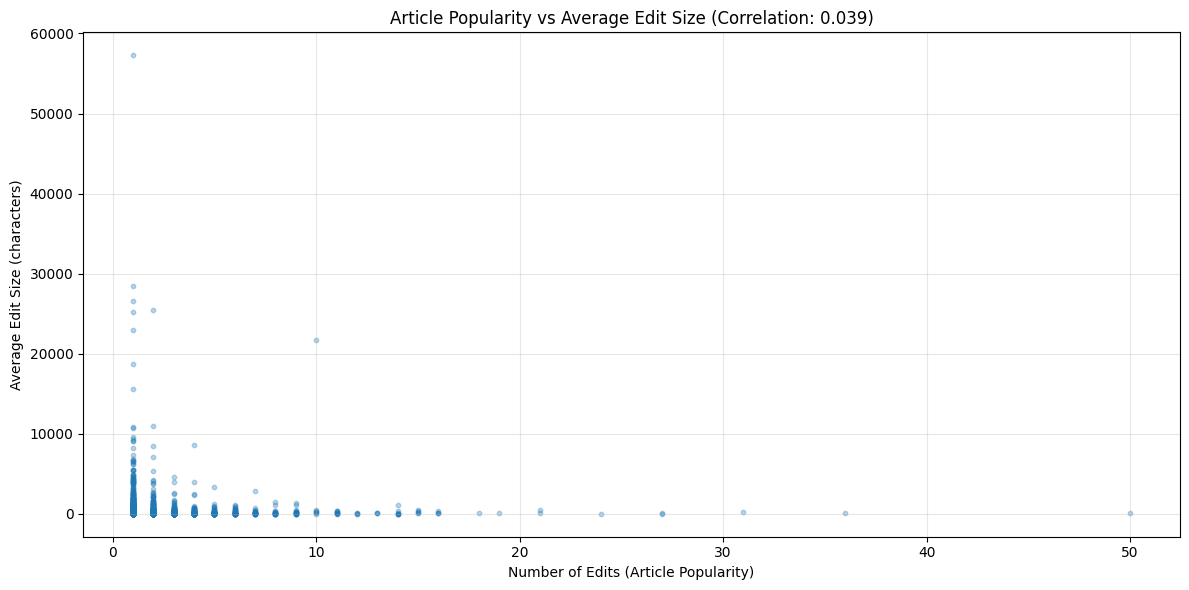

In [21]:
article_edit_stats = df_wiki.withColumn("length_diff", col("length_new") - col("length_old")) \
    .withColumn("abs_length_diff", abs(col("length_new") - col("length_old"))) \
    .groupBy("title") \
    .agg(
        count("*").alias("edit_count"),
        avg("abs_length_diff").alias("avg_edit_size"),
        avg("length_diff").alias("avg_length_change")
    ) \
    .toPandas()

correlation_size = article_edit_stats['edit_count'].corr(article_edit_stats['avg_edit_size'])

fig, ax = plt.subplots(figsize=(12, 6))
plt.scatter(article_edit_stats['edit_count'], article_edit_stats['avg_edit_size'], alpha=0.3, s=10)
plt.xlabel('Number of Edits (Article Popularity)')
plt.ylabel('Average Edit Size (characters)')
plt.title(f'Article Popularity vs Average Edit Size (Correlation: {correlation_size:.3f})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

There is virtually no relationship between how often an article is edited and the size of those edits. Large, one-time edits usually happen on rarely edited pages, while popular, frequently edited pages evolve through many small, incremental changes. This shows that collaboration favors gradual improvements rather than massive rewrites.

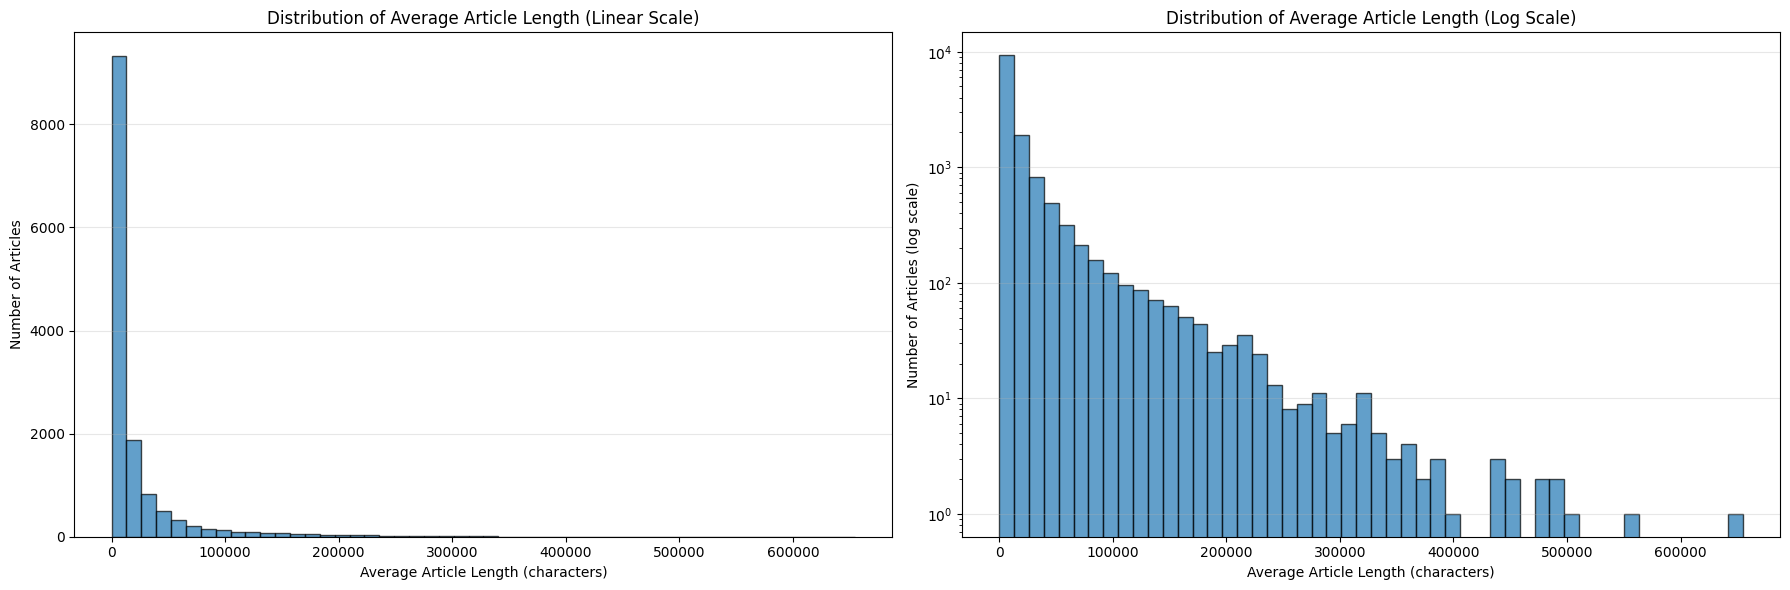

In [22]:
article_lengths = df_wiki.groupBy("title") \
    .agg(avg("length_new").alias("avg_length")) \
    .select("avg_length") \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].hist(article_lengths['avg_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Average Article Length (characters)')
axes[0].set_ylabel('Number of Articles')
axes[0].set_title('Distribution of Average Article Length (Linear Scale)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(article_lengths['avg_length'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Average Article Length (characters)')
axes[1].set_ylabel('Number of Articles (log scale)')
axes[1].set_title('Distribution of Average Article Length (Log Scale)')
axes[1].set_yscale('log')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Most articles on the platform are very short, consisting of stubs or brief entries, while extremely long, book-length articles are rare.

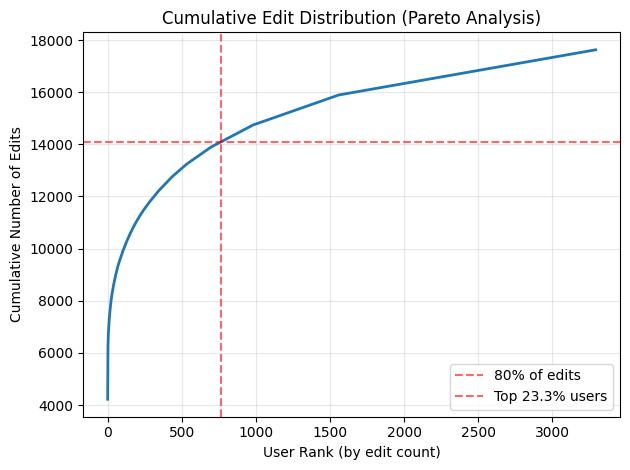

In [23]:
user_edit_counts = df_wiki.groupBy("username") \
    .agg(
        count("*").alias("edit_count"),
        first("bot").alias("is_bot")
    ) \
    .toPandas()

# pareto analysis
user_edit_counts_sorted = (
    user_edit_counts
    .sort_values("edit_count", ascending=False)
    .reset_index(drop=True)
)

user_edit_counts_sorted["cumulative_edits"] = user_edit_counts_sorted["edit_count"].cumsum()
user_edit_counts_sorted["user_rank"] = range(1, len(user_edit_counts_sorted) + 1)

total_edits = user_edit_counts_sorted["cumulative_edits"].iloc[-1]
edits_80 = total_edits * 0.8
users_for_80 = user_edit_counts_sorted[
    user_edit_counts_sorted["cumulative_edits"] >= edits_80
].iloc[0]["user_rank"]

total_users = len(user_edit_counts)

plt.plot(
    user_edit_counts_sorted["user_rank"],
    user_edit_counts_sorted["cumulative_edits"],
    linewidth=2
)
plt.axhline(
    y=edits_80,
    color="red",
    linestyle="--",
    alpha=0.6,
    label="80% of edits"
)
plt.axvline(
    x=users_for_80,
    color="red",
    linestyle="--",
    alpha=0.6,
    label=f"Top {users_for_80 / total_users * 100:.1f}% users"
)
plt.title("Cumulative Edit Distribution (Pareto Analysis)")
plt.xlabel("User Rank (by edit count)")
plt.ylabel("Cumulative Number of Edits")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


A small group of users, about the top 23%, contribute roughly 80% of all edits, confirming the Pareto Principle in this community. Most users make very few edits, while the most active contributors carry the bulk of the workload. This shows that activity is highly concentrated among a dedicated minority.